I will be building off of the chatbot defined in lab1 with my attempt at solving history conversations

### Import Libraries

In [16]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [17]:
load_dotenv(override=True)

True

### Define LLM

In [18]:
llm = ChatOpenAI(model = "gpt-4o-mini")

### Define State

In [19]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

### Define GraphBuilder

In [20]:
graph_builder = StateGraph(State)

### Define Node

In [21]:
def message_node(state:State) -> State:
    response = llm.invoke(state.messages)
    return State(messages=[response])

In [22]:
graph_builder.add_node("message_node", message_node)

### Build Edges

In [23]:
graph_builder.add_edge(START, "message_node")
graph_builder.add_edge("message_node", END)

### Compile Graph

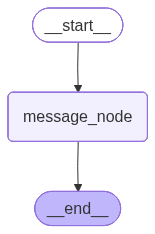

In [24]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### Chat Interface

In [25]:
def chat(user_input: str, history):
    print("test")
    state = State(messages=[{"role" : "user", "content" : user_input}])
    result = graph.invoke(state)
    print(result)
    return result['messages'][-1].content

In [26]:
gr.ChatInterface(chat, type="messages").launch()

c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\utils.py:1052: UserWarning: Expected 1 arguments for function <function chat at 0x000001F37EF74220>, received 2.
  warnings.warn(
c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\utils.py:1060: UserWarning: Expected maximum 1 arguments for function <function chat at 0x000001F37EF74220>, received 2.
  warnings.warn(
c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\utils.py:1052: UserWarning: Expected 1 arguments for function <function chat at 0x000001F37EF742C0>, received 2.
  warnings.warn(
c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\utils.py:1060: UserWarning: Expected maximum 1 arguments for function <function chat at 0x000001F37EF742C0>, received 2.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kimig\OneDrive\Documents\Coding\courses\agents\.venv\Lib\site-packages\gradio\blocks.py", line 1621, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kimig\OneDrive\Documents\Coding\cou